In [1]:
# CELL 1: Install PyG and Mount Drive
from google.colab import drive
drive.mount('/content/drive')

!pip install torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.4.0+cu121.html -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_dense_adj
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
import torch.optim as optim
import matplotlib.pyplot as plt

print("Torch Version:", torch.__version__)
print("✅ Setup Complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 74.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_sparse/_version_cuda.so
  import torch_geometric.typing


Torch Version: 2.10.0+cu128
✅ Setup Complete!


In [2]:
# CELL 2: Load Cora Dataset
DATA_ROOT = '/content/drive/MyDrive/cora/cora'

transform = T.Compose([
    T.NormalizeFeatures(),
    T.RandomLinkSplit(
        num_val=0.1,
        num_test=0.1,
        is_undirected=True,
        add_negative_train_samples=True,
        split_labels=True
    )
])

dataset = Planetoid(root=DATA_ROOT, name='Cora', transform=transform)

data_splits = dataset[0]
data_train = data_splits[0]
data_val = data_splits[1]
data_test = data_splits[2]

print("✅ Cora Dataset Loaded Successfully!")
print(f"Nodes: {data_train.num_nodes:,}")
print(f"Features: {data_train.x.shape[1]}")

Processing...


✅ Cora Dataset Loaded Successfully!
Nodes: 2,708
Features: 1433


Done!


In [3]:
# CELL 3: High-Order Adjacency
def compute_high_order_adjs(data_graph, max_order=4, device='cpu'):
    adj = to_dense_adj(data_graph.edge_index, max_num_nodes=data_graph.num_nodes)[0]
    adj = adj.to(device)
    adj = adj + torch.eye(data_graph.num_nodes, device=device)

    high_order = {}
    current = adj.clone()
    for k in range(1, max_order+1):
        high_order[k] = current.clone()
        current = torch.mm(current, adj)
    print(f"✅ High-order matrices computed up to A^{max_order} on {device}")
    return high_order

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
high_order_adjs = compute_high_order_adjs(data_train, max_order=4, device=device)

✅ High-order matrices computed up to A^4 on cuda


In [4]:
# CELL 4: SEN (Structural Attribution Learning)
class SEN(nn.Module):
    def __init__(self, hidden_dim=8, out_dim=64):
        super().__init__()
        self.f_edge = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.f_node = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, adj_l):
        x = adj_l.unsqueeze(-1)  # [N, N, 1]
        edge_feat = self.f_edge(x)
        node_feat = edge_feat.sum(dim=1)
        return self.f_node(node_feat)

sen = SEN().to(device)
print("✅ SEN Initialized")

✅ SEN Initialized


In [5]:
# CELL 5: Structure-Aware Attention
class SA_Attn(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.WQ = nn.Linear(dim, dim)
        self.WK = nn.Linear(dim, dim)
        self.WR = nn.Linear(dim, dim)
        self.scale = dim ** 0.5

    def forward(self, z, sa):
        Q = self.WQ(z)
        K = self.WK(z)
        R = self.WR(sa)
        scores = (Q @ K.T) + (Q @ R.T)
        scores = scores / self.scale
        attn = F.softmax(scores, dim=-1)
        out = attn @ z
        return out

print("✅ SA-Attn Initialized")

✅ SA-Attn Initialized


In [6]:
# CELL 6: HSAD Model
class HSAD(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, out_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )
        self.sen = SEN(out_dim=out_dim)
        self.sa_attn = SA_Attn(dim=out_dim)

    def forward(self, x, edge_index, high_order_adjs, beta=0.5):
        z = self.mlp(x)                    # Student features

        # Structural Attribution
        sal = 0
        eps = 0.9
        for l in [2, 3, 4]:
            sal += (eps ** (l-2)) * self.sen(high_order_adjs[l])
        sal = sal / 3.0

        # Edge embedding
        src, dst = edge_index
        edge_emb = beta * (z[src] * z[dst]) + (1 - beta) * (sal[src] * sal[dst])

        return z, sal, edge_emb

model = HSAD(in_dim=data_train.x.shape[1]).to(device)
print("✅ HSAD Model Ready!")

✅ HSAD Model Ready!


In [7]:
# CELL 7: Loss
def compute_loss(pred, target):
    L_sup = F.binary_cross_entropy_with_logits(pred, target.float())
    L_edge = F.mse_loss(torch.sigmoid(pred), target.float())
    total_loss = L_sup + 0.5 * L_edge
    return total_loss, L_sup.item()

In [8]:
# CELL 8: Hits@K Evaluation
@torch.no_grad()
def hits_at_k(pred, target, k=20):
    prob = torch.sigmoid(pred)
    _, indices = torch.sort(prob, descending=True)
    top_k = indices[:k]
    hits = target[top_k].sum().item()
    total_pos = target.sum().item()
    return hits / min(k, total_pos) if total_pos > 0 else 0.0

@torch.no_grad()
def evaluate(data_split, k_values=[20, 50]):
    model.eval()
    z, sal, edge_emb = model(
        data_split.x.to(device),
        data_split.edge_index.to(device),
        high_order_adjs
    )

    pos_edge = data_split.edge_index.to(device)
    neg_edge = data_split.neg_edge_label_index.to(device)
    edge_idx = torch.cat([pos_edge, neg_edge], dim=1)

    pos_y = torch.ones(pos_edge.size(1), device=device)
    neg_y = torch.zeros(neg_edge.size(1), device=device)
    y = torch.cat([pos_y, neg_y])

    src, dst = edge_idx
    pred = (z[src] * z[dst]).sum(dim=1)   # You can also try edge_emb.sum(dim=1)

    prob = torch.sigmoid(pred).cpu().numpy()
    labels = y.cpu().numpy()

    auc = roc_auc_score(labels, prob)
    ap = average_precision_score(labels, prob)

    results = {"AUC": auc, "AP": ap}
    for k in k_values:
        hit = hits_at_k(pred, y, k=k)
        results[f"Hits@{k}"] = hit

    return results

In [9]:
# CELL 9: Training
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

def train_one_epoch():
    model.train()
    optimizer.zero_grad()

    z, sal, _ = model(data_train.x.to(device), data_train.edge_index.to(device), high_order_adjs)

    pos_edge = data_train.edge_index.to(device)
    neg_edge = data_train.neg_edge_label_index.to(device)
    edge_idx = torch.cat([pos_edge, neg_edge], dim=1)

    pos_y = torch.ones(pos_edge.size(1), device=device)
    neg_y = torch.zeros(neg_edge.size(1), device=device)
    y = torch.cat([pos_y, neg_y])

    src, dst = edge_idx
    pred = (z[src] * z[dst]).sum(dim=1)

    loss, _ = compute_loss(pred, y)
    loss.backward()
    optimizer.step()
    return loss.item()

print("🚀 Starting Training...\n")
epochs = 300

# Lists for plotting
epoch_list = []
training_loss_list = []
val_auc_list = []
val_hits20_list = []
val_hits50_list = []

for epoch in range(1, epochs+1):
    loss = train_one_epoch()
    if epoch % 50 == 0 or epoch == 1:
        val_res = evaluate(data_val)
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | "
              f"Val AUC: {val_res['AUC']:.4f} | "
              f"Hits@20: {val_res['Hits@20']:.4f} | "
              f"Hits@50: {val_res['Hits@50']:.4f}")

        epoch_list.append(epoch)
        training_loss_list.append(loss)
        val_auc_list.append(val_res['AUC'])
        val_hits20_list.append(val_res['Hits@20'])
        val_hits50_list.append(val_res['Hits@50'])

print("\n✅ Training Complete!")
print("\nFinal Evaluation Results:")
print(f"Val AUC: {val_res['AUC']:.4f}")
print(f"Val AP: {val_res['AP']:.4f}")
print(f"Val Hits@20: {val_res['Hits@20']:.4f}")
print(f"Val Hits@50: {val_res['Hits@50']:.4f}")

🚀 Starting Training...

Epoch   1 | Loss: 0.7699 | Val AUC: 0.5787 | Hits@20: 1.0000 | Hits@50: 0.9800
Epoch  50 | Loss: 0.6367 | Val AUC: 0.6617 | Hits@20: 0.9500 | Hits@50: 0.9800
Epoch 100 | Loss: 0.5786 | Val AUC: 0.7001 | Hits@20: 1.0000 | Hits@50: 1.0000
Epoch 150 | Loss: 0.5223 | Val AUC: 0.7389 | Hits@20: 1.0000 | Hits@50: 1.0000
Epoch 200 | Loss: 0.4039 | Val AUC: 0.8092 | Hits@20: 1.0000 | Hits@50: 1.0000
Epoch 250 | Loss: 0.3599 | Val AUC: 0.8226 | Hits@20: 1.0000 | Hits@50: 1.0000
Epoch 300 | Loss: 0.3451 | Val AUC: 0.8258 | Hits@20: 1.0000 | Hits@50: 1.0000

✅ Training Complete!

Final Evaluation Results:
Val AUC: 0.8258
Val AP: 0.9811
Val Hits@20: 1.0000
Val Hits@50: 1.0000


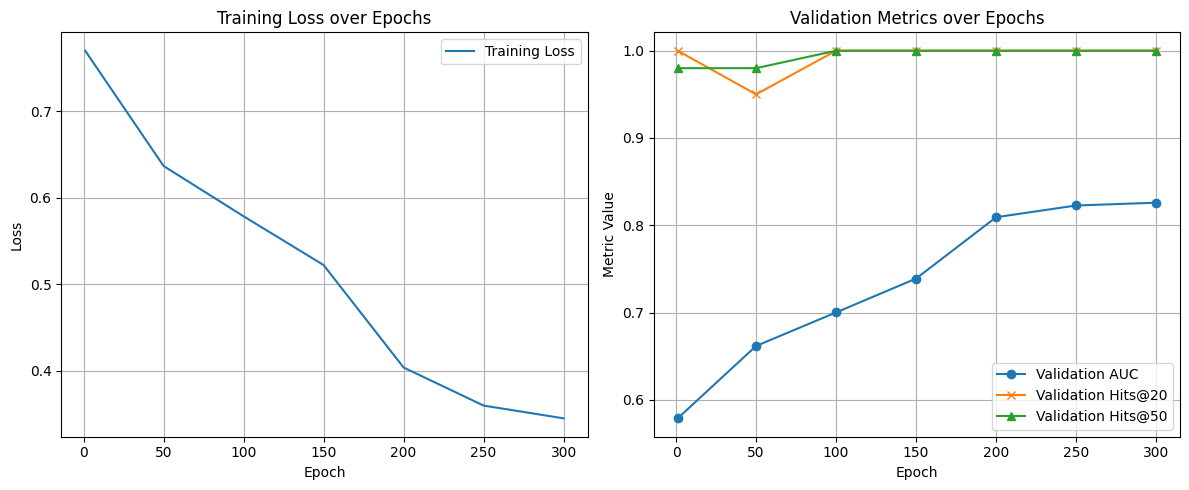

✅ Plots Generated Successfully!


In [10]:
# CELL 10: Plotting Metrics
plt.figure(figsize=(12, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(epoch_list, training_loss_list, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)

# Plot Validation Metrics
plt.subplot(1, 2, 2)
plt.plot(epoch_list, val_auc_list, label='Validation AUC', marker='o')
plt.plot(epoch_list, val_hits20_list, label='Validation Hits@20', marker='x')
plt.plot(epoch_list, val_hits50_list, label='Validation Hits@50', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('Validation Metrics over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("✅ Plots Generated Successfully!")